Calculating the following metrics on the AI-Based model MINST dataset before attack scenario.

# Mapping MNIST to Automated Quality Control Business Process

## Categories in Quality Control Process
The quality control process consists of the following categories:
- **No Defect (ND):** Products that are free from defects and ready for shipping.
- **Defect Type D1:** Represents a specific defect type.
- **Defect Type D2:** Represents another defect type.

## Mapping MNIST Digits to Defect Categories
We map MNIST digits (`0-9`) to the defect categories based on their likelihood of occurrence:
- **Digits 0-6:** Map to **No Defect (ND)** (represents a majority, ~70% of samples).
- **Digit 7:** Map to **Defect Type D1** (~15% of samples).
- **Digits 8-9:** Map to **Defect Type D2** (~15% of samples).

This distribution mirrors real-world manufacturing scenarios where most products are defect-free.

---

# Metrics and Results Description

## Operational Metrics

### 1. Defect Correction Accuracy (DCA)
- **Definition:** Measures the percentage of correctly classified products.
- **Numerator:** Total number of correctly classified samples (both "No Defect" and defects D1, D2).
- **Denominator:** Total number of samples in the test dataset.
- **Formula:**
  \[
  \text{DCA} = \frac{\text{Correctly Classified Products}}{\text{Total Products Processed}} \times 100
  \]

### 2. False Correction Rate (FCR)
- **Definition:** Measures the percentage of misclassified products.
- **Numerator:** Total number of misclassified samples (wrong "No Defect" or wrong defect type).
- **Denominator:** Total number of samples in the test dataset.
- **Formula:**
  \[
  \text{FCR} = \frac{\text{Incorrectly Classified Products}}{\text{Total Products Processed}} \times 100
  \]

### 3. Rework Rate (RR)
- **Definition:** Measures the percentage of products requiring rework due to misclassification.
- Same as **FCR** in this context.
- **Formula:**
  \[
  \text{RR} = \frac{\text{Incorrectly Classified Products}}{\text{Total Products Processed}} \times 100
  \]

### 4. Defect Removal Efficiency (DRE)
- **Definition:** Measures the effectiveness of defect detection and correction.
- **Numerator:** Correctly classified defective products (correct "Defect Type D1" and "Defect Type D2").
- **Denominator:** Total number of defective products (D1 and D2 combined in the ground truth).
- **Formula:**
  \[
  \text{DRE} = \frac{\text{Correctly Classified Defective Products}}{\text{Total Defective Products}} \times 100
  \]

### 5. Defect Resolution Time (DRT)
- **Definition:** The average time taken to process and classify a single product (sample).
- **Numerator:** Total inference time for the entire test dataset.
- **Denominator:** Total number of samples in the test dataset.
- **Formula:**
  \[
  \text{DRT} = \frac{\text{Total Inference Time}}{\text{Total Products Processed}}
  \]

---

## Financial Impact Metrics

### 1. Cost of Defective Products (CDP)
- **Definition:** Financial loss due to undetected or incorrectly corrected defective products.
- **Mapping:**
  - **Number of Defective Products:** Count all samples incorrectly classified as **No Defect** when they are actually **Defect Type D1** or **Defect Type D2**.
  - **Unit Cost of Defective Product:** Fixed cost per defective product (e.g., €10/unit).
- **Formula:**
  \[
  \text{CDP} = \text{Number of Incorrectly Classified Defective Products} \times \text{Unit Cost of Defective Product}
  \]

### 2. Rework Cost (RC)
- **Definition:** Additional cost for reprocessing products that are misclassified and require rework.
- **Mapping:**
  - **Number of Reworked Products:** All misclassified samples (both defective and non-defective).
  - **Rework Cost Per Unit:** Fixed cost for reworking a single product (e.g., €5/unit).
- **Formula:**
  \[
  \text{RC} = \text{Number of Reworked Products} \times \text{Rework Cost Per Unit}
  \]

### 3. Operational Downtime Cost (ODC)
- **Definition:** Cost due to production downtime caused by processing inefficiencies or attack scenarios.
- **Mapping:**
  - **Downtime (hours):** Total downtime based on the number of misclassified samples multiplied by an average delay per product.
  - **Cost Per Hour of Downtime:** Fixed hourly cost for operational downtime (e.g., €50/hour).
- **Formula:**
  \[
  \text{ODC} = \text{Downtime (hours)} \times \text{Cost Per Hour of Downtime}
  \]

### 4. Financial Loss per Defect (FLD)
- **Definition:** Average financial loss for each defect in the system.
- **Mapping:**
  - **Total Financial Loss:** Sum of CDP, RC, and ODC.
  - **Total Number of Defects:** All defective products in the dataset (ground truth for **Defect Type D1** and **Defect Type D2**).
- **Formula:**
  \[
  \text{FLD} = \frac{\text{CDP} + \text{RC} + \text{ODC}}{\text{Total Defective Products}}
  \]

---

## Additional Results

### 1. Ground Truth Counts
- **Definition:** The total number of products in each defect category based on the ground truth labels.
- **Categories:**
  - **No Defect (ND):** Total number of products without defects.
  - **Defect Type D1:** Total number of products with defect type D1.
  - **Defect Type D2:** Total number of products with defect type D2.

### 2. Misclassified Samples
- **Definition:** Samples incorrectly classified as **No Defect**.
- **Details:**
  - List and count of all samples where:
    - **True Label:** "Defect Type D1" or "Defect Type D2".
    - **Predicted Label:** "No Defect".

### 3. Confusion Matrix
- **Definition:** A matrix showing the number of correct and incorrect predictions for each defect category.
- Includes:
  - **True Positives, False Positives, True Negatives, and False Negatives** for each category.

---

# Visualizations
1. **Confusion Matrix Heatmap:**
   - A heatmap representation of the confusion matrix.
   - Provides a clear view of classification performance for each defect category.


In [ ]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Define mapping for MNIST digits to defect categories
def map_to_defect_category(label):
    if label in [0, 1, 2, 3, 4, 5, 6]:  # No Defect
        return "No Defect"
    elif label == 7:  # Defect Type D1
        return "Defect Type D1"
    elif label in [8, 9]:  # Defect Type D2
        return "Defect Type D2"

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Pre-trained model not found. Train and save the model first.")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(64 * 7 * 7, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root="./mnist_data", train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Perform inference
all_preds, all_labels = [], []
start_time = time.time()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
end_time = time.time()

# Total inference time and resolution time per sample
total_inference_time = end_time - start_time
total_samples = len(all_labels)
DRT = total_inference_time / total_samples

# Apply mapping
mapped_labels = [map_to_defect_category(label) for label in all_labels]
mapped_preds = [map_to_defect_category(pred) for pred in all_preds]

# Calculate metrics
unique_categories = ["No Defect", "Defect Type D1", "Defect Type D2"]
cm = confusion_matrix(mapped_labels, mapped_preds, labels=unique_categories)
correct_predictions = np.trace(cm)
total_predictions = np.sum(cm)
incorrect_predictions = total_predictions - correct_predictions

# Ground truth counts
ground_truth_no_defect = cm[0, :].sum()
ground_truth_d1 = cm[1, :].sum()
ground_truth_d2 = cm[2, :].sum()

# Identify samples incorrectly classified as No Defect
incorrect_d1_to_nd = [
    idx for idx, (true, pred) in enumerate(zip(mapped_labels, mapped_preds)) 
    if true == "Defect Type D1" and pred == "No Defect"
]
incorrect_d2_to_nd = [
    idx for idx, (true, pred) in enumerate(zip(mapped_labels, mapped_preds)) 
    if true == "Defect Type D2" and pred == "No Defect"
]

# Defective products (D1 and D2)
total_defective = np.sum(cm[1:, :])  # Rows for D1 and D2 in ground truth
correct_defective = cm[1, 1] + cm[2, 2]  # Correct D1 and D2 predictions

# Financial Impact Metrics
unit_cost_defective = 10  # Example cost per defective product
rework_cost_per_unit = 5  # Example rework cost per product
downtime_per_product = 0.01  # Example downtime (hours) per misclassified product
cost_per_hour_downtime = 50  # Example cost per hour of downtime

CDP = cm[1:, 0].sum() * unit_cost_defective  # Incorrectly classified defective products as "No Defect"
RC = incorrect_predictions * rework_cost_per_unit
ODC = incorrect_predictions * downtime_per_product * cost_per_hour_downtime

# Financial Loss per Defect
FLD = (CDP + RC + ODC) / total_defective if total_defective > 0 else 0

# Metrics
DCA = (correct_predictions / total_predictions) * 100
FCR = (incorrect_predictions / total_predictions) * 100
RR = FCR  # Same as FCR
DRE = (correct_defective / total_defective) * 100 if total_defective > 0 else 0

# Display results
print(f"Total Products Processed: {total_predictions}")
print(f"Correctly Classified Products: {correct_predictions}")
print(f"Incorrectly Classified Products: {incorrect_predictions}")
print(f"Defect Correction Accuracy (DCA): {DCA:.2f}%")
print(f"False Correction Rate (FCR): {FCR:.2f}%")
print(f"Rework Rate (RR): {RR:.2f}%")
print(f"Defect Removal Efficiency (DRE): {DRE:.2f}%")
print(f"Defect Resolution Time (DRT): {DRT:.6f} seconds per product")
print("\nFinancial Impact Metrics:")
print(f"Cost of Defective Products (CDP): €{CDP:.2f}")
print(f"Rework Cost (RC): €{RC:.2f}")
print(f"Operational Downtime Cost (ODC): €{ODC:.2f}")
print(f"Financial Loss per Defect (FLD): €{FLD:.2f}")

# Ground truth counts
print("\nGround Truth Counts:")
print(f"Ground Truth No Defect Products: {ground_truth_no_defect}")
print(f"Ground Truth Defect Type D1 Products: {ground_truth_d1}")
print(f"Ground Truth Defect Type D2 Products: {ground_truth_d2}")

# Misclassified samples as No Defect
print("\nSamples incorrectly classified as No Defect:")
print(f"From Defect Type D1: {len(incorrect_d1_to_nd)} samples, Indices: {incorrect_d1_to_nd}")
print(f"From Defect Type D2: {len(incorrect_d2_to_nd)} samples, Indices: {incorrect_d2_to_nd}")

# Classification Report
print("\nClassification Report:")
print(classification_report(mapped_labels, mapped_preds, target_names=unique_categories))

# Confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_categories, yticklabels=unique_categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (<ipython-input-3-256cae4b2791>, line 22)

# Simulating the Inference Data Poisoning Attack 

/tmp/ipykernel_41992/2468749281.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


=== Results After the Attack on 5% of Test Dataset ===
Total Products Processed: 10000
Correctly Classified Products: 9887
Incorrectly Classified Products: 113
Defect Correction Accuracy (DCA): 98.87%
False Correction Rate (FCR): 1.13%
Rework Rate (RR): 1.13%
Defect Removal Efficiency (DRE): 98.01%
Defect Resolution Time (DRT): 0.000723 seconds per product

Financial Impact Metrics:
Cost of Defective Products (CDP): €400.00
Rework Cost (RC): €565.00
Operational Downtime Cost (ODC): €56.50
Financial Loss per Defect (FLD): €0.34

Ground Truth Counts:
Ground Truth No Defect Products: 6989
Ground Truth Defect Type D1 Products: 1028
Ground Truth Defect Type D2 Products: 1983

Samples incorrectly classified as No Defect:
From Defect Type D1: 8 samples, Indices: [810, 1226, 2024, 5654, 5887, 8375, 9015, 9024]
From Defect Type D2: 32 samples, Indices: [92, 685, 1063, 1232, 1394, 1414, 1559, 1709, 1901, 2129, 2293, 2896, 2939, 3503, 3626, 3662, 3970, 4093, 4163, 4284, 4369, 4823, 5135, 6411, 66

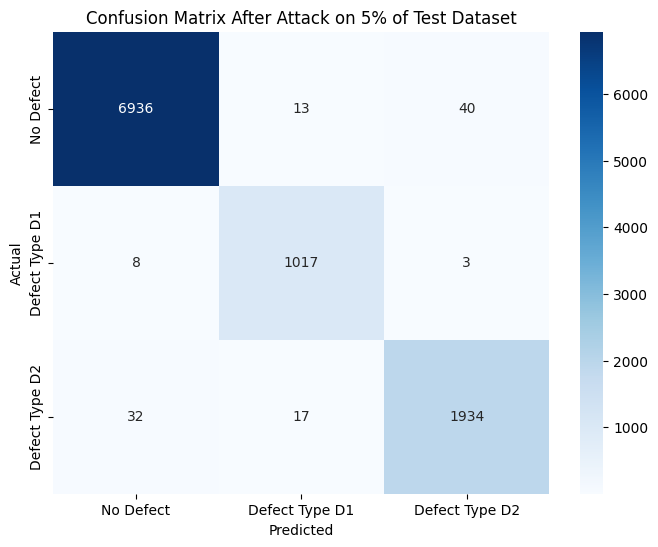

In [3]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

# Define mapping for MNIST digits to defect categories
def map_to_defect_category(label):
    if label in [0, 1, 2, 3, 4, 5, 6]:  # No Defect
        return "No Defect"
    elif label == 7:  # Defect Type D1
        return "Defect Type D1"
    elif label in [8, 9]:  # Defect Type D2
        return "Defect Type D2"

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Pre-trained model not found. Train and save the model first.")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(64 * 7 * 7, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root="./mnist_data", train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# FGSM-based data poisoning function
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def poison_image_with_fgsm(model, image, label, epsilon=0.3):
    image.requires_grad = True
    output = model(image)
    loss = torch.nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    data_grad = image.grad.data
    return fgsm_attack(image, epsilon, data_grad)

# Perform inference with attack on 5% of the dataset
all_preds, all_labels = [], []
poisoned_preds, poisoned_labels = [], []
start_time = time.time()

total_samples = len(test_dataset)
poison_sample_count = int(total_samples * 0.05)  # 5% of the dataset
poison_indices = random.sample(range(total_samples), poison_sample_count)

for i in range(total_samples):
    image, true_label = test_dataset[i]
    image = image.unsqueeze(0).to(device)

    # Apply FGSM attack to selected samples
    if i in poison_indices:
        image = poison_image_with_fgsm(model, image, true_label)
        poisoned_labels.append(true_label)

    with torch.no_grad():
        output = model(image)
        _, predicted_label = torch.max(output, 1)

    all_preds.append(predicted_label.item())
    all_labels.append(true_label)

    if i in poison_indices:
        poisoned_preds.append(predicted_label.item())

end_time = time.time()

# Total inference time and resolution time per sample
total_inference_time = end_time - start_time
DRT = total_inference_time / total_samples

# Apply mapping
mapped_labels = [map_to_defect_category(label) for label in all_labels]
mapped_preds = [map_to_defect_category(pred) for pred in all_preds]

# Calculate metrics
unique_categories = ["No Defect", "Defect Type D1", "Defect Type D2"]
cm = confusion_matrix(mapped_labels, mapped_preds, labels=unique_categories)
correct_predictions = np.trace(cm)
total_predictions = np.sum(cm)
incorrect_predictions = total_predictions - correct_predictions

# Ground truth counts
ground_truth_no_defect = cm[0, :].sum()
ground_truth_d1 = cm[1, :].sum()
ground_truth_d2 = cm[2, :].sum()

# Identify samples incorrectly classified as No Defect
incorrect_d1_to_nd = [
    idx for idx, (true, pred) in enumerate(zip(mapped_labels, mapped_preds)) 
    if true == "Defect Type D1" and pred == "No Defect"
]
incorrect_d2_to_nd = [
    idx for idx, (true, pred) in enumerate(zip(mapped_labels, mapped_preds)) 
    if true == "Defect Type D2" and pred == "No Defect"
]

# Defective products (D1 and D2)
total_defective = np.sum(cm[1:, :])
correct_defective = cm[1, 1] + cm[2, 2]

# Financial Impact Metrics
unit_cost_defective = 10
rework_cost_per_unit = 5
downtime_per_product = 0.01
cost_per_hour_downtime = 50

CDP = cm[1:, 0].sum() * unit_cost_defective
RC = incorrect_predictions * rework_cost_per_unit
ODC = incorrect_predictions * downtime_per_product * cost_per_hour_downtime
FLD = (CDP + RC + ODC) / total_defective if total_defective > 0 else 0

# Metrics
DCA = (correct_predictions / total_predictions) * 100
FCR = (incorrect_predictions / total_predictions) * 100
RR = FCR
DRE = (correct_defective / total_defective) * 100 if total_defective > 0 else 0

# Print results
print("=== Results After the Attack on 5% of Test Dataset ===")
print(f"Total Products Processed: {total_predictions}")
print(f"Correctly Classified Products: {correct_predictions}")
print(f"Incorrectly Classified Products: {incorrect_predictions}")
print(f"Defect Correction Accuracy (DCA): {DCA:.2f}%")
print(f"False Correction Rate (FCR): {FCR:.2f}%")
print(f"Rework Rate (RR): {RR:.2f}%")
print(f"Defect Removal Efficiency (DRE): {DRE:.2f}%")
print(f"Defect Resolution Time (DRT): {DRT:.6f} seconds per product")
print("\nFinancial Impact Metrics:")
print(f"Cost of Defective Products (CDP): €{CDP:.2f}")
print(f"Rework Cost (RC): €{RC:.2f}")
print(f"Operational Downtime Cost (ODC): €{ODC:.2f}")
print(f"Financial Loss per Defect (FLD): €{FLD:.2f}")

# Ground truth counts
print("\nGround Truth Counts:")
print(f"Ground Truth No Defect Products: {ground_truth_no_defect}")
print(f"Ground Truth Defect Type D1 Products: {ground_truth_d1}")
print(f"Ground Truth Defect Type D2 Products: {ground_truth_d2}")

# Misclassified samples as No Defect
print("\nSamples incorrectly classified as No Defect:")
print(f"From Defect Type D1: {len(incorrect_d1_to_nd)} samples, Indices: {incorrect_d1_to_nd}")
print(f"From Defect Type D2: {len(incorrect_d2_to_nd)} samples, Indices: {incorrect_d2_to_nd}")

# Classification Report
print("\nClassification Report:")
print(classification_report(mapped_labels, mapped_preds, target_names=unique_categories))

# Confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_categories, yticklabels=unique_categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix After Attack on 5% of Test Dataset")
plt.show()


/tmp/ipykernel_41992/3403139811.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


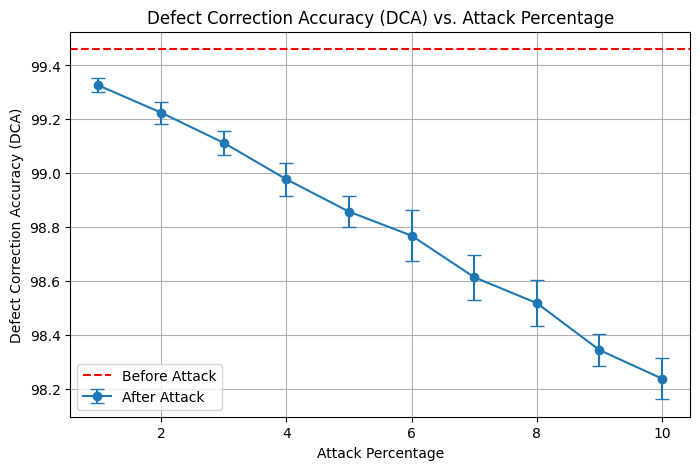

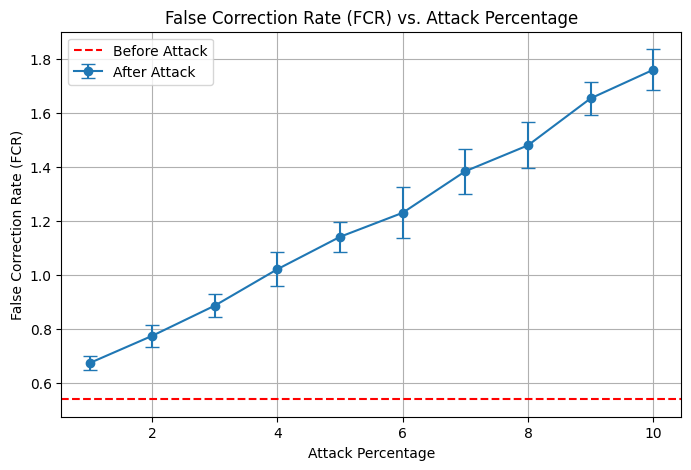

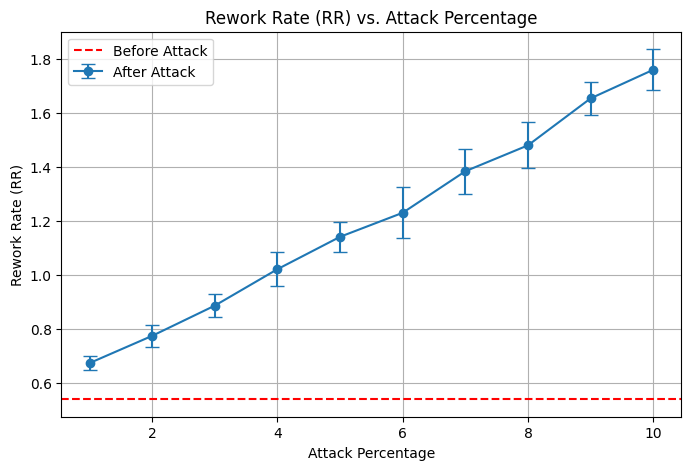

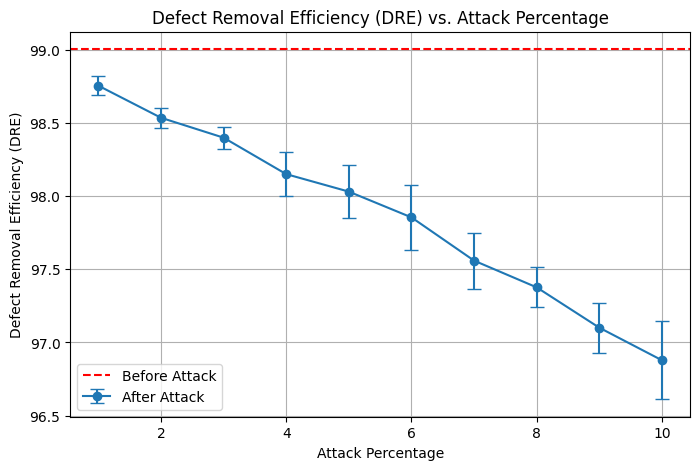

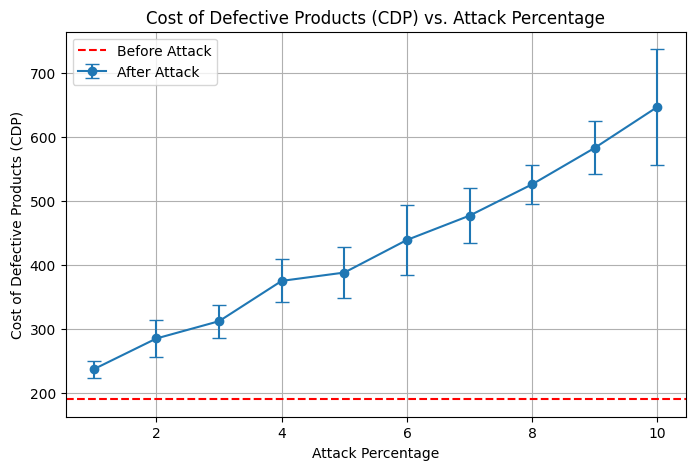

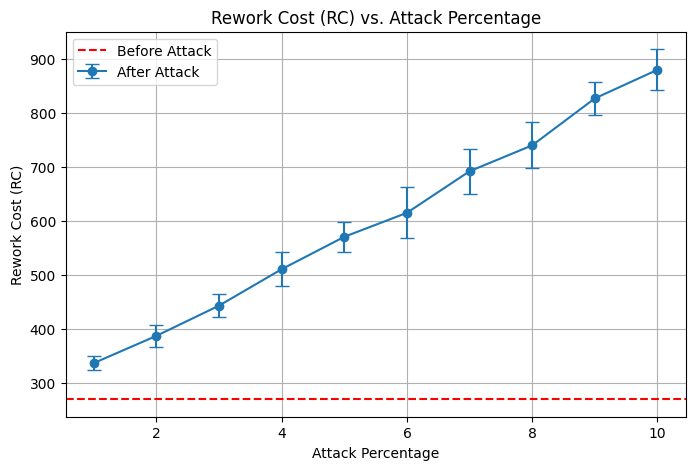

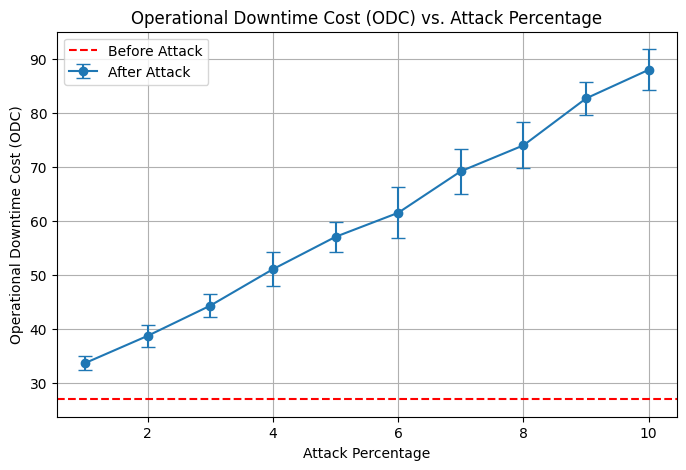

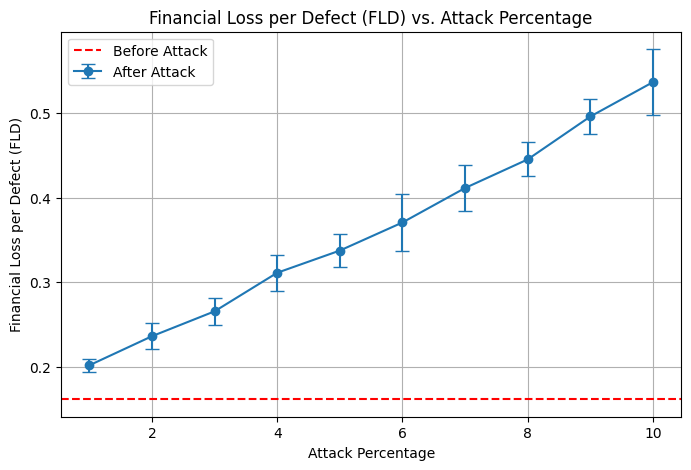

In [5]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

# Define mapping for MNIST digits to defect categories
def map_to_defect_category(label):
    if label in [0, 1, 2, 3, 4, 5, 6]:  # No Defect
        return "No Defect"
    elif label == 7:  # Defect Type D1
        return "Defect Type D1"
    elif label in [8, 9]:  # Defect Type D2
        return "Defect Type D2"

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Pre-trained model not found. Train and save the model first.")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(64 * 7 * 7, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root="./mnist_data", train=False, transform=transform)

# FGSM-based data poisoning function
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def poison_image_with_fgsm(model, image, label, epsilon=0.3):
    image.requires_grad = True
    output = model(image)
    loss = torch.nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    data_grad = image.grad.data
    return fgsm_attack(image, epsilon, data_grad)

# Function to calculate metrics
def calculate_metrics(mapped_labels, mapped_preds, total_inference_time, total_samples, cm):
    correct_predictions = np.trace(cm)
    total_predictions = np.sum(cm)
    incorrect_predictions = total_predictions - correct_predictions

    total_defective = np.sum(cm[1:, :])
    correct_defective = cm[1, 1] + cm[2, 2]

    unit_cost_defective = 10
    rework_cost_per_unit = 5
    downtime_per_product = 0.01
    cost_per_hour_downtime = 50

    CDP = cm[1:, 0].sum() * unit_cost_defective
    RC = incorrect_predictions * rework_cost_per_unit
    ODC = incorrect_predictions * downtime_per_product * cost_per_hour_downtime
    FLD = (CDP + RC + ODC) / total_defective if total_defective > 0 else 0

    DCA = (correct_predictions / total_predictions) * 100
    FCR = (incorrect_predictions / total_predictions) * 100
    RR = FCR
    DRE = (correct_defective / total_defective) * 100 if total_defective > 0 else 0
    DRT = total_inference_time / total_samples

    return {"DCA": DCA, "FCR": FCR, "RR": RR, "DRE": DRE, "CDP": CDP, "RC": RC, "ODC": ODC, "FLD": FLD, "DRT": DRT}

# Run experiments
results = {"before_attack": None, "after_attack": {}}

# Run inference without attack
start_time = time.time()
all_preds, all_labels = [], []
for i in range(len(test_dataset)):
    image, label = test_dataset[i]
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    all_preds.append(predicted.item())
    all_labels.append(label)
end_time = time.time()

mapped_labels = [map_to_defect_category(label) for label in all_labels]
mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
results["before_attack"] = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)

# Run inference with attack (1% to 10%) over multiple iterations
iterations = 10
for percentage in range(1, 11):
    metrics_list = []
    for _ in range(iterations):
        all_preds, all_labels = [], []
        poison_indices = random.sample(range(len(test_dataset)), int(len(test_dataset) * (percentage / 100)))
        start_time = time.time()
        for i in range(len(test_dataset)):
            image, label = test_dataset[i]
            image = image.unsqueeze(0).to(device)
            if i in poison_indices:
                image = poison_image_with_fgsm(model, image, label)
            with torch.no_grad():
                output = model(image)
                _, predicted = torch.max(output, 1)
            all_preds.append(predicted.item())
            all_labels.append(label)
        end_time = time.time()

        mapped_labels = [map_to_defect_category(label) for label in all_labels]
        mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
        cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
        metrics = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)
        metrics_list.append(metrics)

    results["after_attack"][percentage] = {
        "mean": {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]},
        "variance": {key: np.var([m[key] for m in metrics_list]) for key in metrics_list[0]},
    }

# Plot metrics with mean and variance
def plot_metrics_with_error(results, metric_name, ylabel):
    percentages = range(1, 11)
    means = [results["after_attack"][p]["mean"][metric_name] for p in percentages]
    variances = [results["after_attack"][p]["variance"][metric_name] for p in percentages]
    plt.figure(figsize=(8, 5))
    plt.errorbar(percentages, means, yerr=np.sqrt(variances), fmt="o-", capsize=5, label="After Attack")
    plt.axhline(y=results["before_attack"][metric_name], color="r", linestyle="--", label="Before Attack")
    plt.xlabel("Attack Percentage")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs. Attack Percentage")
    plt.legend()
    plt.grid()
    plt.show()

metrics_to_plot = {"DCA": "Defect Correction Accuracy (DCA)", "FCR": "False Correction Rate (FCR)", 
                   "RR": "Rework Rate (RR)", "DRE": "Defect Removal Efficiency (DRE)", 
                   "CDP": "Cost of Defective Products (CDP)", "RC": "Rework Cost (RC)", 
                   "ODC": "Operational Downtime Cost (ODC)", "FLD": "Financial Loss per Defect (FLD)"}

for metric, ylabel in metrics_to_plot.items():
    plot_metrics_with_error(results, metric, ylabel)


In [10]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import random
import time

# Define mapping for MNIST digits to defect categories
def map_to_defect_category(label):
    if label in [0, 1, 2, 3, 4, 5, 6]:  # No Defect
        return "No Defect"
    elif label == 7:  # Defect Type D1
        return "Defect Type D1"
    elif label in [8, 9]:  # Defect Type D2
        return "Defect Type D2"

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Pre-trained model not found. Train and save the model first.")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(64 * 7 * 7, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root="./mnist_data", train=False, transform=transform)

# FGSM-based data poisoning function
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * data_grad
    return torch.clamp(perturbed_image, 0, 1)

def poison_image_with_fgsm(model, image, label, epsilon=0.3):
    image.requires_grad = True
    output = model(image)
    loss = torch.nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    data_grad = image.grad.data
    return fgsm_attack(image, epsilon, data_grad)

# Function to calculate metrics
def calculate_metrics(mapped_labels, mapped_preds, total_inference_time, total_samples, cm):
    correct_predictions = np.trace(cm)
    total_predictions = np.sum(cm)
    incorrect_predictions = total_predictions - correct_predictions

    total_defective = np.sum(cm[1:, :])
    correct_defective = cm[1, 1] + cm[2, 2]

    unit_cost_defective = 10
    rework_cost_per_unit = 5
    downtime_per_product = 0.01
    cost_per_hour_downtime = 50

    CDP = cm[1:, 0].sum() * unit_cost_defective
    RC = incorrect_predictions * rework_cost_per_unit
    ODC = incorrect_predictions * downtime_per_product * cost_per_hour_downtime
    FLD = (CDP + RC + ODC) / total_defective if total_defective > 0 else 0

    DCA = (correct_predictions / total_predictions) * 100
    FCR = (incorrect_predictions / total_predictions) * 100
    RR = FCR
    DRE = (correct_defective / total_defective) * 100 if total_defective > 0 else 0
    DRT = total_inference_time / total_samples

    return {
        "DCA": DCA, "FCR": FCR, "RR": RR, "DRE": DRE, "CDP": CDP,
        "RC": RC, "ODC": ODC, "FLD": FLD, "DRT": DRT, "confusion_matrix": cm
    }

# Create results directory
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# Run inference without attack
print("=== Running Before Attack Case ===")
start_time = time.time()
all_preds, all_labels = [], []
for i in tqdm(range(len(test_dataset)), desc="Processing Samples (Before Attack)"):
    image, label = test_dataset[i]
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    all_preds.append(predicted.item())
    all_labels.append(label)
end_time = time.time()

mapped_labels = [map_to_defect_category(label) for label in all_labels]
mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
before_attack_metrics = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)

# Save results for before attack
before_attack_file = os.path.join(results_dir, "before_attack_metrics.xlsx")
pd.DataFrame([before_attack_metrics]).to_excel(before_attack_file, index=False)

# Save confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(before_attack_metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Defect", "Defect Type D1", "Defect Type D2"],
            yticklabels=["No Defect", "Defect Type D1", "Defect Type D2"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Before Attack)")
plt.savefig(os.path.join(results_dir, "confusion_matrix_before_attack.png"))
plt.close()

# Run inference with attack
print("\n=== Running After Attack Case ===")
iterations = 10
after_attack_results = {}

for percentage in tqdm(range(1, 11), desc="Processing Attack Percentages"):
    metrics_list = []
    for _ in range(iterations):
        all_preds, all_labels = [], []
        poison_indices = random.sample(range(len(test_dataset)), int(len(test_dataset) * (percentage / 100)))
        start_time = time.time()
        for i in range(len(test_dataset)):
            image, label = test_dataset[i]
            image = image.unsqueeze(0).to(device)
            if i in poison_indices:
                image = poison_image_with_fgsm(model, image, label)
            with torch.no_grad():
                output = model(image)
                _, predicted = torch.max(output, 1)
            all_preds.append(predicted.item())
            all_labels.append(label)
        end_time = time.time()

        mapped_labels = [map_to_defect_category(label) for label in all_labels]
        mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
        cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
        metrics = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)
        metrics_list.append(metrics)

    after_attack_results[percentage] = {
        "mean": {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]},
        "variance": {key: np.var([m[key] for m in metrics_list]) for key in metrics_list[0]}
    }

# Save attack results to Excel
after_attack_file = os.path.join(results_dir, "after_attack_metrics.xlsx")
data = []
for percentage, values in after_attack_results.items():
    mean = values["mean"]
    mean["attack_percentage"] = percentage
    mean.update({"variance_" + k: v for k, v in values["variance"].items()})
    data.append(mean)
pd.DataFrame(data).to_excel(after_attack_file, index=False)

# Plot metrics (line plots and bar plots)
def plot_metric(metric_name, ylabel):
    percentages = list(after_attack_results.keys())
    means = [after_attack_results[p]["mean"][metric_name] for p in percentages]
    variances = [after_attack_results[p]["variance"][metric_name] for p in percentages]

    # Line plot
    plt.figure(figsize=(10, 6))
    plt.errorbar(percentages, means, yerr=np.sqrt(variances), fmt="o-", capsize=5, label="After Attack")
    plt.axhline(y=before_attack_metrics[metric_name], color="red", linestyle="--", label="Before Attack")
    plt.xlabel("Attack Percentage")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Comparison")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(results_dir, f"{metric_name}_line_plot.png"))
    plt.close()

    # Bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(percentages, means, yerr=np.sqrt(variances), capsize=5, label="After Attack", alpha=0.7)
    plt.axhline(y=before_attack_metrics[metric_name], color="red", linestyle="--", label="Before Attack")
    plt.xlabel("Attack Percentage")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Comparison")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(results_dir, f"{metric_name}_bar_plot.png"))
    plt.close()

metrics_to_plot = {
    "DCA": "Defect Correction Accuracy (DCA)",
    "FCR": "False Correction Rate (FCR)",
    "RR": "Rework Rate (RR)",
    "DRE": "Defect Removal Efficiency (DRE)",
    "CDP": "Cost of Defective Products (CDP)",
    "RC": "Rework Cost (RC)",
    "ODC": "Operational Downtime Cost (ODC)",
    "FLD": "Financial Loss per Defect (FLD)"
}

for metric, ylabel in metrics_to_plot.items():
    plot_metric(metric, ylabel)

print("\nAll results and plots saved to the results directory.")
import os
import torch
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import random
import time

# Define mapping for MNIST digits to defect categories
def map_to_defect_category(label):
    if label in [0, 1, 2, 3, 4, 5, 6]:  # No Defect
        return "No Defect"
    elif label == 7:  # Defect Type D1
        return "Defect Type D1"
    elif label in [8, 9]:  # Defect Type D2
        return "Defect Type D2"

# Load pre-trained model
model_path = "./cnn_mnist_model.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError("Pre-trained model not found. Train and save the model first.")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(64 * 7 * 7, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model and dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = MNIST(root="./mnist_data", train=False, transform=transform)

# FGSM-based data poisoning function
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * data_grad
    return torch.clamp(perturbed_image, 0, 1)

def poison_image_with_fgsm(model, image, label, epsilon=0.3):
    image.requires_grad = True
    output = model(image)
    loss = torch.nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model.zero_grad()
    loss.backward()
    data_grad = image.grad.data
    return fgsm_attack(image, epsilon, data_grad)

# Function to calculate metrics
def calculate_metrics(mapped_labels, mapped_preds, total_inference_time, total_samples, cm):
    correct_predictions = np.trace(cm)
    total_predictions = np.sum(cm)
    incorrect_predictions = total_predictions - correct_predictions

    total_defective = np.sum(cm[1:, :])
    correct_defective = cm[1, 1] + cm[2, 2]

    unit_cost_defective = 10
    rework_cost_per_unit = 5
    downtime_per_product = 0.01
    cost_per_hour_downtime = 50

    CDP = cm[1:, 0].sum() * unit_cost_defective
    RC = incorrect_predictions * rework_cost_per_unit
    ODC = incorrect_predictions * downtime_per_product * cost_per_hour_downtime
    FLD = (CDP + RC + ODC) / total_defective if total_defective > 0 else 0

    DCA = (correct_predictions / total_predictions) * 100
    FCR = (incorrect_predictions / total_predictions) * 100
    RR = FCR
    DRE = (correct_defective / total_defective) * 100 if total_defective > 0 else 0
    DRT = total_inference_time / total_samples

    return {
        "DCA": DCA, "FCR": FCR, "RR": RR, "DRE": DRE, "CDP": CDP,
        "RC": RC, "ODC": ODC, "FLD": FLD, "DRT": DRT, "confusion_matrix": cm
    }

# Create results directory
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# Run inference without attack
print("=== Running Before Attack Case ===")
start_time = time.time()
all_preds, all_labels = [], []
for i in tqdm(range(len(test_dataset)), desc="Processing Samples (Before Attack)"):
    image, label = test_dataset[i]
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    all_preds.append(predicted.item())
    all_labels.append(label)
end_time = time.time()

mapped_labels = [map_to_defect_category(label) for label in all_labels]
mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
before_attack_metrics = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)

# Save results for before attack
before_attack_file = os.path.join(results_dir, "before_attack_metrics.xlsx")
pd.DataFrame([before_attack_metrics]).to_excel(before_attack_file, index=False)

# Save confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(before_attack_metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Defect", "Defect Type D1", "Defect Type D2"],
            yticklabels=["No Defect", "Defect Type D1", "Defect Type D2"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Before Attack)")
plt.savefig(os.path.join(results_dir, "confusion_matrix_before_attack.png"))
plt.close()

# Run inference with attack
print("\n=== Running After Attack Case ===")
iterations = 10
after_attack_results = {}

for percentage in tqdm(range(1, 11), desc="Processing Attack Percentages"):
    metrics_list = []
    for _ in range(iterations):
        all_preds, all_labels = [], []
        poison_indices = random.sample(range(len(test_dataset)), int(len(test_dataset) * (percentage / 100)))
        start_time = time.time()
        for i in range(len(test_dataset)):
            image, label = test_dataset[i]
            image = image.unsqueeze(0).to(device)
            if i in poison_indices:
                image = poison_image_with_fgsm(model, image, label)
            with torch.no_grad():
                output = model(image)
                _, predicted = torch.max(output, 1)
            all_preds.append(predicted.item())
            all_labels.append(label)
        end_time = time.time()

        mapped_labels = [map_to_defect_category(label) for label in all_labels]
        mapped_preds = [map_to_defect_category(pred) for pred in all_preds]
        cm = confusion_matrix(mapped_labels, mapped_preds, labels=["No Defect", "Defect Type D1", "Defect Type D2"])
        metrics = calculate_metrics(mapped_labels, mapped_preds, end_time - start_time, len(test_dataset), cm)
        metrics_list.append(metrics)

    after_attack_results[percentage] = {
        "mean": {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]},
        "variance": {key: np.var([m[key] for m in metrics_list]) for key in metrics_list[0]}
    }

# Save attack results to Excel
after_attack_file = os.path.join(results_dir, "after_attack_metrics.xlsx")
data = []
for percentage, values in after_attack_results.items():
    mean = values["mean"]
    mean["attack_percentage"] = percentage
    mean.update({"variance_" + k: v for k, v in values["variance"].items()})
    data.append(mean)
pd.DataFrame(data).to_excel(after_attack_file, index=False)

# Plot metrics (line plots and bar plots)
def plot_metric(metric_name, ylabel):
    percentages = list(after_attack_results.keys())
    means = [after_attack_results[p]["mean"][metric_name] for p in percentages]
    variances = [after_attack_results[p]["variance"][metric_name] for p in percentages]

    # Line plot
    plt.figure(figsize=(10, 6))
    plt.errorbar(percentages, means, yerr=np.sqrt(variances), fmt="o-", capsize=5, label="After Attack")
    plt.axhline(y=before_attack_metrics[metric_name], color="red", linestyle="--", label="Before Attack")
    plt.xlabel("Attack Percentage")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Comparison")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(results_dir, f"{metric_name}_line_plot.png"))
    plt.close()

    # Bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(percentages, means, yerr=np.sqrt(variances), capsize=5, label="After Attack", alpha=0.7)
    plt.axhline(y=before_attack_metrics[metric_name], color="red", linestyle="--", label="Before Attack")
    plt.xlabel("Attack Percentage")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Comparison")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(results_dir, f"{metric_name}_bar_plot.png"))
    plt.close()

metrics_to_plot = {
    "DCA": "Defect Correction Accuracy (DCA)",
    "FCR": "False Correction Rate (FCR)",
    "RR": "Rework Rate (RR)",
    "DRE": "Defect Removal Efficiency (DRE)",
    "CDP": "Cost of Defective Products (CDP)",
    "RC": "Rework Cost (RC)",
    "ODC": "Operational Downtime Cost (ODC)",
    "FLD": "Financial Loss per Defect (FLD)"
}

for metric, ylabel in metrics_to_plot.items():
    plot_metric(metric, ylabel)

print("\nAll results and plots saved to the results directory.")


/tmp/ipykernel_41992/1922642688.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


=== Running Before Attack Case ===


Processing Samples (Before Attack): 100%|██████████| 10000/10000 [00:09<00:00, 1056.65it/s]



=== Running After Attack Case ===


Processing Attack Percentages: 100%|██████████| 10/10 [09:26<00:00, 56.65s/it]
/tmp/ipykernel_41992/1922642688.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.lo


All results and plots saved to the results directory.
=== Running Before Attack Case ===


Processing Samples (Before Attack): 100%|██████████| 10000/10000 [00:12<00:00, 769.82it/s]



=== Running After Attack Case ===


Processing Attack Percentages: 100%|██████████| 10/10 [09:23<00:00, 56.30s/it]



All results and plots saved to the results directory.
